# Deskripsi Data

Dataset ini berisi 16.411 pengukuran sensor harian pada tanaman, mencakup kondisi lingkungan dan tahap pertumbuhan bibit. Setiap baris merepresentasikan satu pengukuran unik dengan variabel lingkungan dan output indikator kebutuhan irigasi. Dataset ini cocok digunakan untuk analisis smart farming dan model prediksi kebutuhan irigasi.

Features:
*  crop_id: Jenis tanaman (categorical)
*  soil_type: Jenis tanah (misal: Black Soil, Red Soil)
* seedling_stage: Tahap pertumbuhan bibit (misal: Germination, Flowering)
*  moi: Moisture Index, kelembaban tanah saat pengukuran (integer)
*  temp: Suhu lingkungan dalam °C (integer)
*  humidity: Kelembaban udara (%)
*  result: Indikator kebutuhan irigasi (0 = rendah, 1 = sedang, 2 = tinggi)
*  datetime: Timestamp pengukuran



Potential Use Cases:
Prediksi kebutuhan irigasi berbasis kondisi lingkungan, Penelitian pengaruh tanah dan cuaca terhadap pertumbuhan tanaman, Integrasi ke sistem IoT smart farming untuk automasi irigasi

Dataset Stats:
Total record: 16.411 baris, Missing values: 0 (dataset lengkap)
Kategori utama:
*  crop_id: Wheat 38%, Chilli 17%, lainnya 45%
*  soil_type: Clay Soil 23%, Sandy Soil 22%, lainnya 55%
*  seedling_stage: Flowering 18%, Seedling Stage 18%, lainnya 64%

# Import  

In [ ]:
!pip install kagglehub pandas matplotlib seaborn

In [ ]:
import kagglehub

path = kagglehub.dataset_download("chaitanyagopidesi/smart-agriculture-dataset")

print("Path dataset:", path)

Using Colab cache for faster access to the 'smart-agriculture-dataset' dataset.
Path dataset: /kaggle/input/smart-agriculture-dataset


# Load Data

In [ ]:
import pandas as pd
import os

# lihat isi folder
print(os.listdir(path))

# load csv
df = pd.read_csv(os.path.join(path, "cropdata_updated.csv"))

# lihat 5 data pertama
df.head()

['cropdata_updated.csv']


,crop ID,soil_type,Seedling Stage,MOI,temp,humidity,result
0,Wheat,Black Soil,Germination,1,25,80.0,1
1,Wheat,Black Soil,Germination,2,26,77.0,1
2,Wheat,Black Soil,Germination,3,27,74.0,1
3,Wheat,Black Soil,Germination,4,28,71.0,1
4,Wheat,Black Soil,Germination,5,29,68.0,1


In [ ]:
df.shape

(16411, 7)

In [ ]:
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16411 entries, 0 to 16410
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   crop ID         16411 non-null  object 
 1   soil_type       16411 non-null  object 
 2   Seedling Stage  16411 non-null  object 
 3   MOI             16411 non-null  int64  
 4   temp            16411 non-null  int64  
 5   humidity        16411 non-null  float64
 6   result          16411 non-null  int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 897.6+ KB


In [ ]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print(df.columns.tolist())

['crop_id', 'soil_type', 'seedling_stage', 'moi', 'temp', 'humidity', 'result']


# EDA

In [ ]:
print("Statistik umum dataset:")
display(df.describe(include='all'))
print("Jumlah missing values per kolom:")
display(df.isnull().sum())
print("Jumlah data duplikat:")
print(df.duplicated().sum())

Statistik umum dataset:


,crop_id,soil_type,seedling_stage,moi,temp,humidity,result
count,16411,16411,16411,16411.000000,16411.000000,16411.000000,16411.000000
unique,5,7,8,NaN,NaN,NaN,NaN
top,Wheat,Clay Soil,Flowering,NaN,NaN,NaN,NaN
freq,6213,3726,3002,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,43.695387,28.832612,63.487752,0.516178
std,NaN,NaN,NaN,27.160264,9.701465,22.630965,0.621691
min,NaN,NaN,NaN,1.000000,13.000000,15.000000,0.000000
25%,NaN,NaN,NaN,21.000000,20.000000,44.000000,0.000000
50%,NaN,NaN,NaN,41.000000,28.000000,69.200000,0.000000
75%,NaN,NaN,NaN,64.000000,37.000000,84.000000,1.000000


Jumlah missing values per kolom:


,0
crop_id,0
soil_type,0
seedling_stage,0
moi,0
temp,0
humidity,0
result,0


Jumlah data duplikat:
128


In [ ]:
print("Distribusi target result:")
display(df['result'].value_counts())

print("\nDistribusi target result dalam persentase:")
display(df['result'].value_counts(normalize=True) * 100)

Distribusi target result:


,count
result,
0,9062
1,6227
2,1122



Distribusi target result dalam persentase:


,proportion
result,
0,55.219060
1,37.944062
2,6.836878


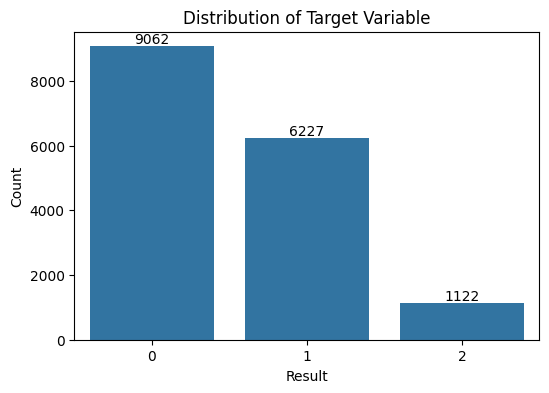

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6,4))

ax = sns.countplot(x='result', data=df)

plt.title("Distribution of Target Variable")
plt.xlabel("Result")
plt.ylabel("Count")

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

plt.show()

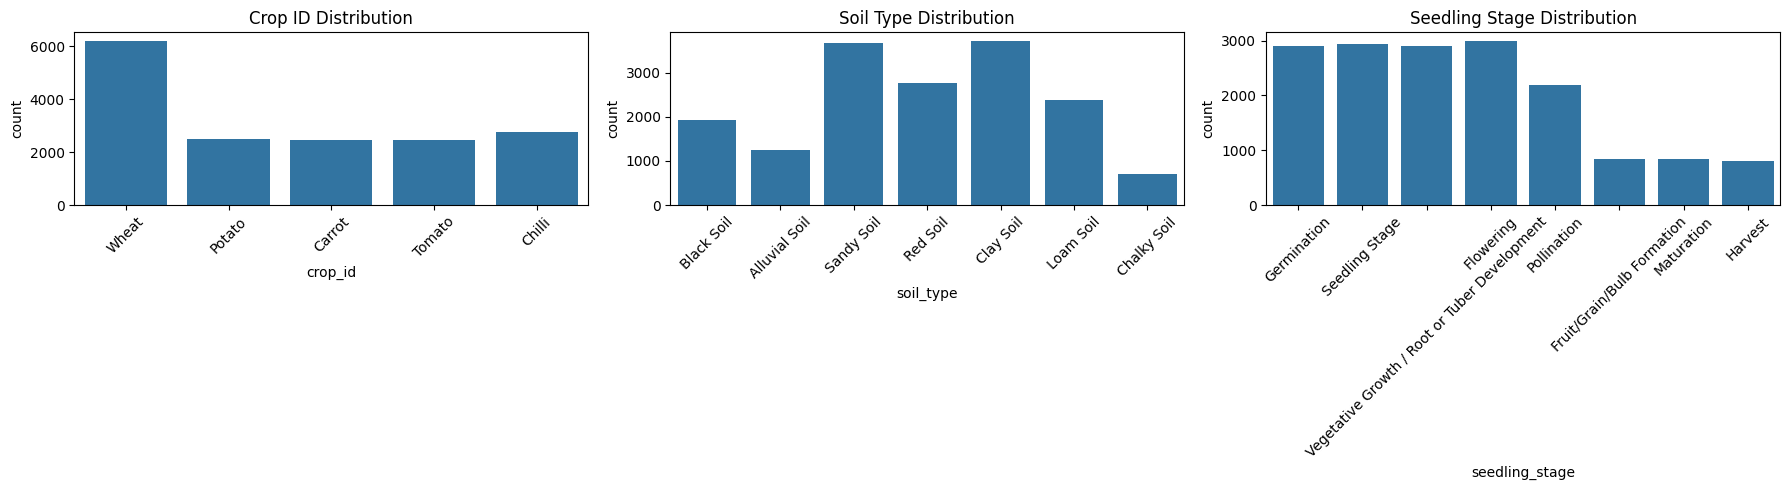

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.countplot(x='crop_id', data=df, ax=axes[0])
axes[0].set_title("Crop ID Distribution")
axes[0].tick_params(axis='x', rotation=45)

sns.countplot(x='soil_type', data=df, ax=axes[1])
axes[1].set_title("Soil Type Distribution")
axes[1].tick_params(axis='x', rotation=45)

sns.countplot(x='seedling_stage', data=df, ax=axes[2])
axes[2].set_title("Seedling Stage Distribution")
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

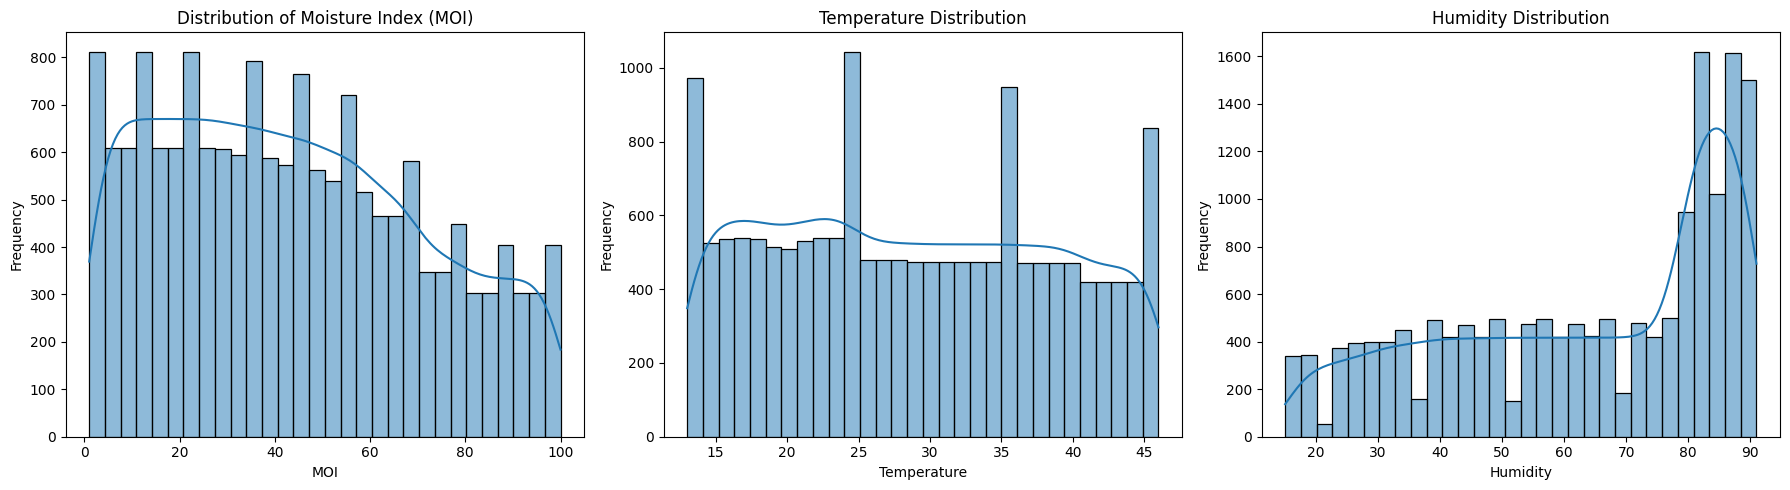

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['moi'], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Moisture Index (MOI)")
axes[0].set_xlabel("MOI")
axes[0].set_ylabel("Frequency")

sns.histplot(df['temp'], bins=30, kde=True, ax=axes[1])
axes[1].set_title("Temperature Distribution")
axes[1].set_xlabel("Temperature")
axes[1].set_ylabel("Frequency")

sns.histplot(df['humidity'], bins=30, kde=True, ax=axes[2])
axes[2].set_title("Humidity Distribution")
axes[2].set_xlabel("Humidity")
axes[2].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

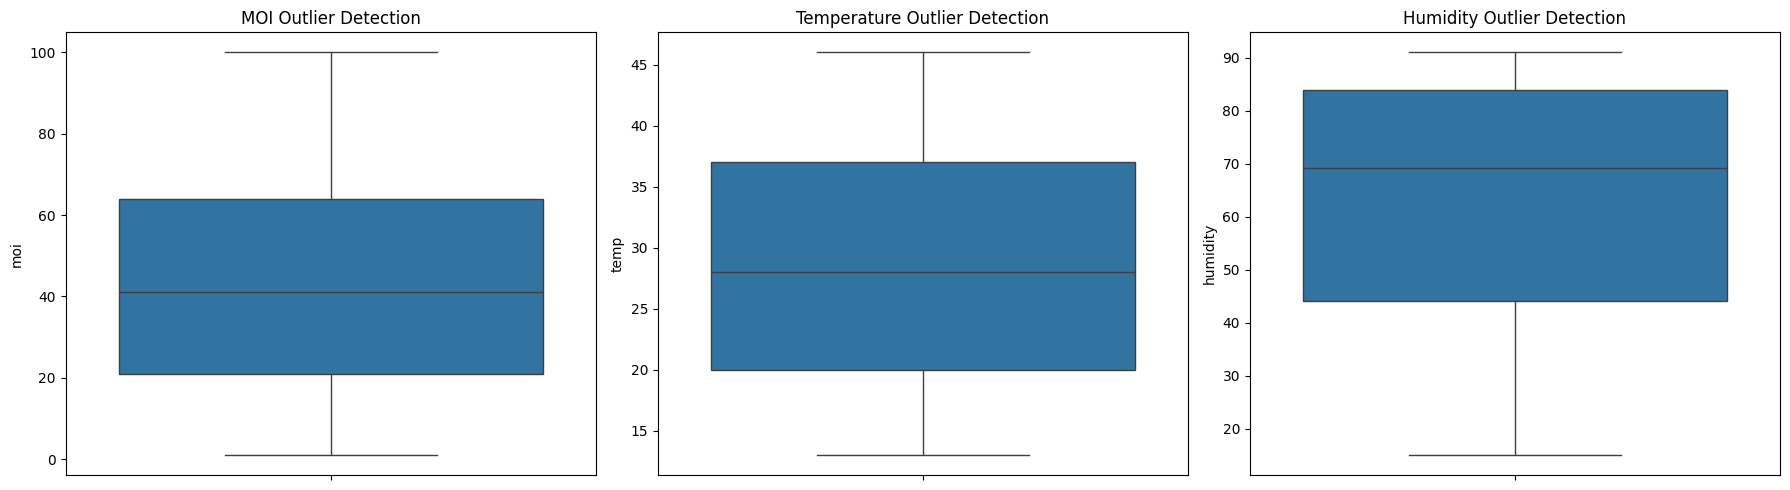

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.boxplot(y=df['moi'], ax=axes[0])
axes[0].set_title("MOI Outlier Detection")

sns.boxplot(y=df['temp'], ax=axes[1])
axes[1].set_title("Temperature Outlier Detection")

sns.boxplot(y=df['humidity'], ax=axes[2])
axes[2].set_title("Humidity Outlier Detection")

plt.tight_layout()
plt.show()

# Data Cleaning

In [ ]:
# STEP 7 — DATA CLEANING

df_clean = df.copy()

print("Shape sebelum cleaning:", df_clean.shape)

# Hapus duplikasi
df_clean = df_clean.drop_duplicates()

print("Shape setelah hapus duplikasi:", df_clean.shape)
print("Jumlah duplikasi setelah cleaning:", df_clean.duplicated().sum())

# Fungsi IQR capping
def cap_outliers_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return series.clip(lower=lower_bound, upper=upper_bound)

# Tangani outlier pada MOI dan humidity
df_clean['moi'] = cap_outliers_iqr(df_clean['moi'])
df_clean['humidity'] = cap_outliers_iqr(df_clean['humidity'])

# Temperature dipertahankan

Shape sebelum cleaning: (16411, 7)
Shape setelah hapus duplikasi: (16283, 7)
Jumlah duplikasi setelah cleaning: 0


In [ ]:
print("Missing values setelah cleaning:")
display(df_clean.isnull().sum())

print("Statistik numerik setelah cleaning:")
display(df_clean[['moi', 'temp', 'humidity']].describe())

Missing values setelah cleaning:


,0
crop_id,0
soil_type,0
seedling_stage,0
moi,0
temp,0
humidity,0
result,0


Statistik numerik setelah cleaning:


,moi,temp,humidity
count,16283.000000,16283.000000,16283.000000
mean,43.781858,28.912547,63.316004
std,27.198158,9.692754,22.634381
min,1.000000,13.000000,15.000000
25%,21.000000,21.000000,44.000000
50%,41.000000,29.000000,69.000000
75%,64.000000,37.000000,83.000000
max,100.000000,46.000000,91.000000


In [ ]:
import pandas as pd

# Tambahkan datetime sintetis
df_clean['datetime'] = pd.date_range(
    start='2023-01-01',
    periods=len(df_clean),
    freq='H'
)

# Jadikan index
df_clean['datetime'] = pd.to_datetime(df_clean['datetime'])
df_clean = df_clean.set_index('datetime')

# Cek 5 data pertama
df_clean.head()

/tmp/ipykernel_432/1531730933.py:6: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_clean['datetime'] = pd.date_range(


,crop_id,soil_type,seedling_stage,moi,temp,humidity,result
datetime,,,,,,,
2023-01-01 00:00:00,Wheat,Black Soil,Germination,1,25,80.0,1
2023-01-01 01:00:00,Wheat,Black Soil,Germination,2,26,77.0,1
2023-01-01 02:00:00,Wheat,Black Soil,Germination,3,27,74.0,1
2023-01-01 03:00:00,Wheat,Black Soil,Germination,4,28,71.0,1
2023-01-01 04:00:00,Wheat,Black Soil,Germination,5,29,68.0,1


In [ ]:
print("Jumlah data duplikat sebelum:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("Jumlah data duplikat setelah:", df.duplicated().sum())

Jumlah data duplikat sebelum: 128
Jumlah data duplikat setelah: 0


# Analisis dan Visualisasi

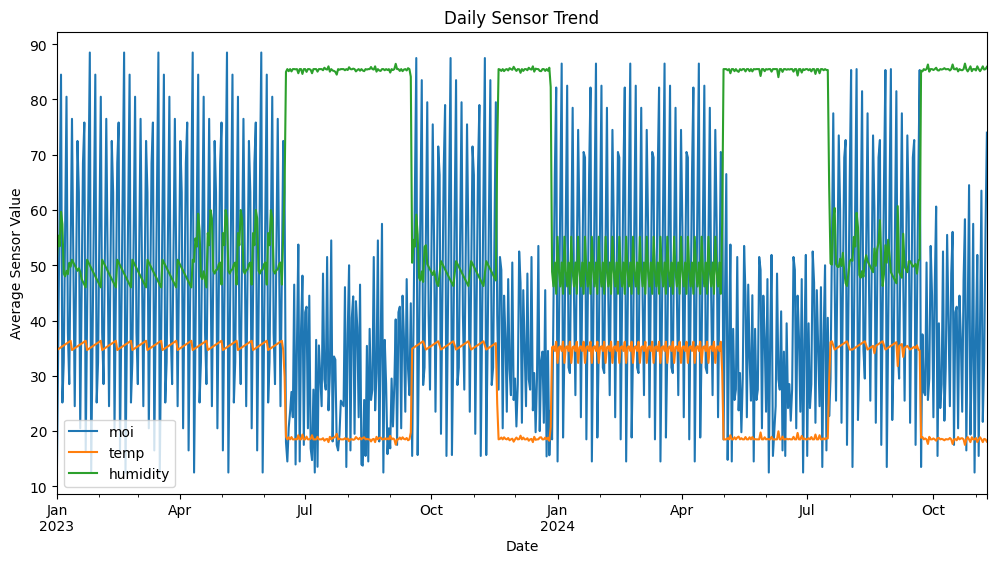

In [ ]:
# Resample per hari untuk membuat trend
daily_trend = df_clean[['moi','temp','humidity']].resample('D').mean()

plt.figure(figsize=(12,6))
daily_trend.plot(ax=plt.gca())
plt.title("Daily Sensor Trend")
plt.xlabel("Date")
plt.ylabel("Average Sensor Value")
plt.show()

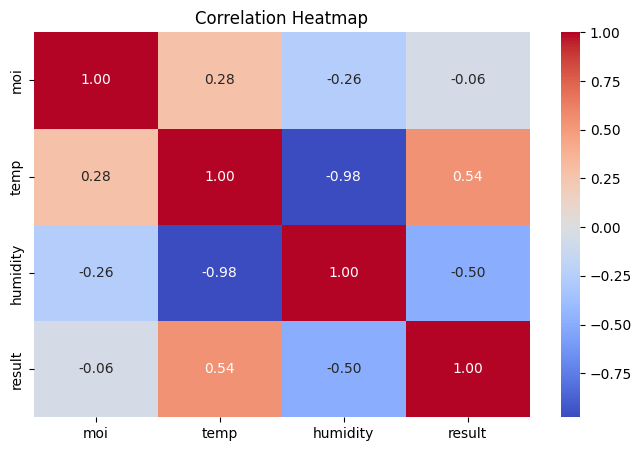

In [ ]:
plt.figure(figsize=(8,5))
sns.heatmap(
    df_clean[['moi','temp','humidity','result']].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# =========================
# DATA QUALITY SCORE
# =========================
total_cells = df.shape[0] * df.shape[1]  # total sel dataset
missing_cells = df.isnull().sum().sum()  # jumlah sel yang kosong
non_null_cells = total_cells - missing_cells

accuracy = 1 - (missing_cells / total_cells)
completeness = non_null_cells / total_cells

# Asumsikan semua data terbaru dalam 30 hari terakhir
timeliness = 1.0

print("📊 Data Quality Score")
print(f"Accuracy    : {accuracy:.2%}")
print(f"Completeness: {completeness:.2%}")
print(f"Timeliness  : {timeliness:.2%}")

📊 Data Quality Score
Accuracy    : 100.00%
Completeness: 100.00%
Timeliness  : 100.00%


In [ ]:
import os

os.makedirs("outputs", exist_ok=True)
df_clean.to_csv("outputs/cleaned_data.csv")
print("Saved to outputs/cleaned_data.csv")

Saved to outputs/cleaned_data.csv


# Deployment

In [ ]:
!pip install streamlit plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 105.4 MB/s eta 0:00:00


In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path

st.set_page_config(page_title="Smart Farming Dashboard", layout="wide")

st.title("🌱 Smart Farming Sensor Dashboard")

# =========================
# LOAD DATA
# =========================
@st.cache_data
def load_data():
    possible_paths = [
        Path("outputs/cleaned_data.csv"),
        Path("../outputs/cleaned_data.csv"),
        Path("cleaned_data.csv")
    ]
    for path in possible_paths:
        if path.exists():
            df = pd.read_csv(path)
            break
    else:
        st.error("File cleaned_data.csv tidak ditemukan.")
        st.stop()

    # pastikan datetime jadi index
    if "datetime" in df.columns:
        df["datetime"] = pd.to_datetime(df["datetime"])
        df = df.set_index("datetime")
    return df

df = load_data()

# =========================
# SIDEBAR FILTER
# =========================
st.sidebar.title("Filter Dashboard")

crop_options = ["All"] + sorted(df["crop_id"].dropna().unique().tolist())
soil_options = ["All"] + sorted(df["soil_type"].dropna().unique().tolist())
stage_options = ["All"] + sorted(df["seedling_stage"].dropna().unique().tolist())

selected_crop = st.sidebar.selectbox("Crop ID", crop_options)
selected_soil = st.sidebar.selectbox("Soil Type", soil_options)
selected_stage = st.sidebar.selectbox("Seedling Stage", stage_options)

date_min = df.index.min().date()
date_max = df.index.max().date()
selected_date = st.sidebar.date_input("Date Range", value=(date_min, date_max), min_value=date_min, max_value=date_max)

if isinstance(selected_date, tuple) and len(selected_date) == 2:
    start_date, end_date = selected_date
else:
    start_date, end_date = date_min, date_max

# filter dataframe
filtered_df = df.copy()
if selected_crop != "All":
    filtered_df = filtered_df[filtered_df["crop_id"] == selected_crop]
if selected_soil != "All":
    filtered_df = filtered_df[filtered_df["soil_type"] == selected_soil]
if selected_stage != "All":
    filtered_df = filtered_df[filtered_df["seedling_stage"] == selected_stage]

filtered_df = filtered_df[(filtered_df.index.date >= start_date) & (filtered_df.index.date <= end_date)]

if filtered_df.empty:
    st.warning("Tidak ada data untuk kombinasi filter yang dipilih.")
    st.stop()

# =========================
# KPI SECTION
# =========================
latest = filtered_df.iloc[-1]

avg_moi = filtered_df["moi"].mean()
avg_temp = filtered_df["temp"].mean()
avg_humidity = filtered_df["humidity"].mean()
dominant_result = filtered_df["result"].mode()[0]

col1, col2, col3, col4 = st.columns(4)
col1.metric("Average MOI", f"{avg_moi:.2f}")
col2.metric("Average Temperature", f"{avg_temp:.2f} °C")
col3.metric("Average Humidity", f"{avg_humidity:.2f} %")
col4.metric("Dominant Result", f"{dominant_result}")

# =========================
# ALERT SYSTEM
# =========================
st.subheader("🚨 Smart Alert System")

alert_messages = []

moi_threshold = df["moi"].quantile(0.25)
humidity_threshold = df["humidity"].quantile(0.25)
temp_high_threshold = df["temp"].quantile(0.75)

if latest["moi"] < moi_threshold:
    alert_messages.append(f"MOI rendah ({latest['moi']:.2f})")
if latest["humidity"] < humidity_threshold:
    alert_messages.append(f"Humidity rendah ({latest['humidity']:.2f}%)")
if latest["temp"] > temp_high_threshold:
    alert_messages.append(f"Temperature tinggi ({latest['temp']:.2f}°C)")

if alert_messages:
    for msg in alert_messages:
        st.error(msg)
else:
    st.success("Semua sensor dalam rentang aman.")

# =========================
# GAUGE METERS
# =========================
st.subheader("📟 Real-Time Gauge")

g1, g2, g3 = st.columns(3)

with g1:
    fig_moi = go.Figure(go.Indicator(
        mode="gauge+number",
        value=float(latest["moi"]),
        title={"text": "Current MOI"},
        gauge={"axis":{"range":[0,100]}},
    ))
    st.plotly_chart(fig_moi, use_container_width=True)

with g2:
    fig_temp = go.Figure(go.Indicator(
        mode="gauge+number",
        value=float(latest["temp"]),
        title={"text": "Current Temperature"},
        gauge={"axis":{"range":[0,50]}},
    ))
    st.plotly_chart(fig_temp, use_container_width=True)

with g3:
    fig_humidity = go.Figure(go.Indicator(
        mode="gauge+number",
        value=float(latest["humidity"]),
        title={"text": "Current Humidity"},
        gauge={"axis":{"range":[0,100]}},
    ))
    st.plotly_chart(fig_humidity, use_container_width=True)

# =========================
# TIME SERIES TREND
# =========================
st.subheader("📈 Time Series Trend")
ts_df = filtered_df[["moi","temp","humidity"]].resample("D").mean().reset_index()
fig_ts = px.line(ts_df, x="datetime", y=["moi","temp","humidity"], title="Sensor Trend Over Time")
st.plotly_chart(fig_ts, use_container_width=True)

# =========================
# CORRELATION HEATMAP
# =========================
st.subheader("🔥 Correlation Heatmap")
corr = filtered_df[["moi","temp","humidity","result"]].corr()
fig_corr = px.imshow(corr, text_auto=".2f", color_continuous_scale="RdBu_r")
st.plotly_chart(fig_corr, use_container_width=True)

# =========================
# RESULT DISTRIBUTION
# =========================
st.subheader("📊 Target Distribution")
result_counts = filtered_df["result"].value_counts().sort_index().reset_index()
result_counts.columns = ["result","count"]
fig_result = px.bar(result_counts, x="result", y="count", text="count")
st.plotly_chart(fig_result, use_container_width=True)

# =========================
# DATA PREVIEW
# =========================
st.subheader("🗂 Data Preview")
st.dataframe(filtered_df.tail(20))

Writing app.py


In [ ]:
!mkdir -p .streamlit

In [ ]:
%%writefile .streamlit/config.toml
[theme]
primaryColor="#00E6AC"
backgroundColor="#0E1117"
secondaryBackgroundColor="#1C1F24"
textColor="#FFFFFF"
font="sans serif"

Writing .streamlit/config.toml


In [ ]:
%%writefile requirements.txt
streamlit
pandas
numpy
plotly
matplotlib
seaborn

Writing requirements.txt
